### 유방암 데이터셋을 활용한 이진분류 다층 퍼셉트론 모델

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler # 평균 0, 표준편차 1 표준화 도구

In [57]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [58]:
cancer.data # 입력 특성 데이터

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [59]:
cancer.feature_names # 각 열의 특성 이름

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [60]:
cancer.target # 종양이 악성(0) 또는 양성(1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [61]:
df = pd.DataFrame(cancer.data, columns = cancer.feature_names)
df['class'] = cancer.target

df.head

<bound method NDFrame.head of      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean conca

In [62]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


2. Pytorch 텐서로 변환

In [63]:
import torch                         # 텐서 연산 + 자동 미분 + GPU 지원
import torch.nn as nn                # 신경망 레이어
import torch.nn.functional as F      # 활성화, 손실 함수
import torch.optim as optim          # 가중치 업데이트 알고리즘

torch.from_numpy() : numpy 배열을 Pytorch 텐서로 변환                                                                     
df.values : DataFrame을 Numpy 배열형태로 변환                                                              
float() : 텐서를 float32 데이터 타입으로 변환                                                

In [64]:
data = torch.from_numpy(df.values).float()

data.shape

torch.Size([569, 31])

In [65]:
x = data[:,:-1]
y = data[:,-1:]

print(x.size(), y.size()) #[569, 30] [569,1]

torch.Size([569, 30]) torch.Size([569, 1])


In [66]:
ratio = [.6,.2,.2] # 학습/검증/테스트 비율

In [67]:
train_cnt = int(data.size(0) * ratio[0])
valid_cnt = int(data.size(0) * ratio[1])
test_cnt = data.size(0) - train_cnt - valid_cnt

cnts = [train_cnt, valid_cnt, test_cnt]

print(f"학습/검증/테스트 데이터셋 수 : {train_cnt}, {valid_cnt},{test_cnt}")


학습/검증/테스트 데이터셋 수 : 341, 113,115


In [68]:
indices = torch.randperm(data.size(0)) # 0 ~ n-1개(568)까지 숫자를 무작위로 섞은 텐서

x = torch.index_select(x,dim = 0, index = indices) # 섞인 인덱스 순서대로 x 재정렬
y = torch.index_select(y,dim = 0, index = indices)

x = x.split(cnts, dim = 0) # x를 train/valid/test 개수 기준으로 분할
y = y.split(cnts, dim = 0) # y도 동일하게 처리

for x_i, y_i in zip(x,y):
    print(x_i.size(), y_i.size())

torch.Size([341, 30]) torch.Size([341, 1])
torch.Size([113, 30]) torch.Size([113, 1])
torch.Size([115, 30]) torch.Size([115, 1])


3. 전처리

In [69]:
scaler = StandardScaler()   # 평균 0, 표준편차 1 정규화 도구
scaler.fit(x[0].numpy())    # 학습 데이터 기준으로 스케일 기준 학습

x = [
    torch.from_numpy(scaler.transform(x[0].numpy())).float(), # train 데이터 정규화 (FloatTensor형태로 최종 변환)
    torch.from_numpy(scaler.transform(x[1].numpy())).float(), # valid 데이터 정규화 (FloatTensor형태로 최종 변환)
    torch.from_numpy(scaler.transform(x[2].numpy())).float(), # valid 데이터 정규화 (FloatTensor형태로 최종 변환)
]

df = pd.DataFrame(x[0].numpy(), columns = cancer.feature_names)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-0.615051,0.777389,-0.567689,-0.619955,-2.005146,0.084472,-0.123400,-0.507900,-2.189433,0.602179,...,-0.788854,0.495039,-0.614236,-0.705803,-1.998088,0.484321,0.092225,-0.077157,-1.153685,0.622470
1,-1.484142,-0.094226,-1.350399,-1.216302,0.284781,1.821915,1.367813,0.008761,1.920983,3.711532,...,-1.310554,-0.362627,-1.174766,-1.041042,-0.420892,0.844952,0.917016,0.005120,0.438139,1.345496
2,-0.326124,-1.248774,-0.401761,-0.377075,-0.935305,-1.267410,-1.069014,-1.068758,-1.277628,-1.100208,...,-0.339901,-1.331740,-0.416824,-0.383356,-1.368782,-1.291346,-1.234440,-1.224055,-1.295331,-1.044521
3,-0.259671,0.220651,-0.208598,-0.334249,0.618492,0.786020,0.117073,0.343386,0.622573,0.785695,...,0.210897,0.380360,0.155671,0.028114,1.007877,0.828744,0.457718,0.543796,1.456637,1.176931
4,-0.230779,2.602762,-0.249661,-0.299049,-0.261087,-0.554072,-0.770557,-0.431337,-1.562111,-0.357186,...,-0.273390,2.578633,-0.335167,-0.325175,-0.647461,-0.726560,-0.982726,-0.567243,-1.145254,-0.385310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,-0.675725,-0.139860,-0.602048,-0.641075,1.131895,0.940631,0.411729,0.082111,1.815214,2.303073,...,0.094502,0.399743,0.344110,-0.004306,1.502630,2.213863,2.057726,0.627624,3.179990,3.434503
337,-0.496591,-1.479228,-0.564337,-0.533422,-1.675209,-1.207884,-1.035999,-0.997523,-0.694073,-0.361662,...,-0.659988,-1.499720,-0.737469,-0.625892,-1.702162,-1.248800,-1.241731,-1.356318,-1.003609,-0.774816
338,0.390413,3.250769,0.477740,0.251538,0.784593,1.178346,1.084903,0.943302,1.049297,0.588750,...,0.441609,3.859478,0.550495,0.252075,2.640097,2.071367,1.448731,1.354138,1.073858,2.242504
339,-0.473477,-0.283609,-0.539615,-0.490595,-1.626889,-1.477101,-1.111514,-1.159240,-1.004087,-1.597048,...,-0.549828,-0.753503,-0.630388,-0.535291,-1.769670,-1.393998,-1.305687,-1.518542,-1.082863,-1.682059


4. 모델 & 옵티마이저 구성
- 입력 특성 x[0].size(-1) => 30
- 은닉층 25 -> 20 -> 15 -> 5 노드로 점차 축소하는 방식
- 각 은닉층 사이사이에 LeakyReLU 함수 적용
- 출력층 y[0].size(-1) => 1개 노드
- 출력층 활성화함수 Sigmod => 0 ~ 1 이진 분류 확률값 출력

In [70]:
model = nn.Sequential(
    nn.Linear(x[0].size(-1), 25), # 입력 특성수 -> 은닉층 25개 노드
    nn.LeakyReLU(),               # 음수 영역도 기울기 어느정도 유지하는 활성화함수

    nn.Linear(25,20),             # 은닉층 25개 노드 -> 은닉층 20개 노드
    nn.LeakyReLU(),               

    nn.Linear(20,15),             # 은닉층 20개 노드 -> 은닉층 15개 노드
    nn.LeakyReLU(),

    nn.Linear(15,10),
    nn.LeakyReLU(),

    nn.Linear(10,5),
    nn.LeakyReLU(),
    

    nn.Linear(5, y[0].size(-1)),   # 은닉층 5개 노드 -> 이진 분류는 1개
    nn.Sigmoid()
)

model

Sequential(
  (0): Linear(in_features=30, out_features=25, bias=True)
  (1): LeakyReLU(negative_slope=0.01)
  (2): Linear(in_features=25, out_features=20, bias=True)
  (3): LeakyReLU(negative_slope=0.01)
  (4): Linear(in_features=20, out_features=15, bias=True)
  (5): LeakyReLU(negative_slope=0.01)
  (6): Linear(in_features=15, out_features=10, bias=True)
  (7): LeakyReLU(negative_slope=0.01)
  (8): Linear(in_features=10, out_features=5, bias=True)
  (9): LeakyReLU(negative_slope=0.01)
  (10): Linear(in_features=5, out_features=1, bias=True)
  (11): Sigmoid()
)

In [71]:
#Adam 계열 최적화함수: 학습률을 자동 조절해주는 대표 옵티마이저

optimizer = optim.Adam(model.parameters())

5. 학습

In [72]:
n_epochs = 10000        # 학습 반복 횟수
batch_size = 32         # 한번에 학습할 샘플 수 (미니배치 크기)
print_interval = 100    # loss 출력
early_stop = 1000       # 성능 개선 없을 경우 중단할 

In [73]:
# 모델 저장 설정
from copy import deepcopy # 객체 완전 복사 (best_model 저장용)

lowest_loss = np.inf      # 최소 손실값 (매우 큰 값 초기화)
best_model = None         # 최고 성능 모델 저장

lowest_epoch = np.inf     # 최소 손실이 나온 epoch 가족

In [74]:
train_history, valid_history = [], []

for i in range(n_epochs):
    indices = torch.randperm(x[0].size(0))   # 0 ~ n-1 개(568)까지 숫자를 무작위로 섞은 텐서
    x_ = torch.index_select(x[0], dim = 0, index = indices) # 섞인 인덱스 순서대로 x 재정렬
    y_ = torch.index_select(y[0], dim = 0, index = indices) # 섞인 인덱스 순서대로 y 재정렬

    x_ = x_.split(batch_size, dim = 0)       # 배치 크기 단위로 분할
    y_ = y_.split(batch_size, dim = 0)       # y도 동일하게 처리

    train_loss, valid_loss = 0, 0   # epoch별 손실 초기화
    y_hat = []                      # 검증 예측값 저장


    # 미니배치 단위로 학습
    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)        # 순전파 진행(예측)
        loss = F.binary_cross_entropy(y_hat_i, y_i)  # 이진 분류 손실 계산

        optimizer.zero_grad()       # 이전 기울기값 초기화
        loss.backward()             # 역전파: 기울기 재계산
 
        optimizer.step()            # 가중치 업데이트
        train_loss += float(loss)   #Tensor -> float 형태로 epochs별 train_loss 총합

    train_loss = train_loss / len(x_) #평균 학습 손실 게산

    # 검증 단계 (기울기 계산 하지 않음)
    with torch.no_grad():
        x_ = x[1].split(batch_size, dim = 0)   # 검증 데이터도 배치 분할
        y_ = y[1].split(batch_size, dim = 0)   # 검증 데이터도 배치 분할

        valid_loss = 0

        # 배치단위로 검증 데이터 순회
        for x_i, y_i in zip(x_, y_):
            y_hat_i = model(x_i)   # 순전파 (예측)
            loss = F.binary_cross_entropy(y_hat_i, y_i)  # 검증 손실 계산

            valid_loss += float(loss)   # epochs별 valid_loss 총합

            y_hat += [y_hat_i]          # 예측값 저장

    valid_loss = valid_loss / len(x_)   # 평균 검증 손실


    # 시각화용 기록
    train_history += [train_loss]   # epochs별 학습 손실
    valid_history += [valid_loss]   # epochs별 검증 손실

# 로그 확인용
    if (i+1) % print_interval == 0:   # 100번마다 한번씩
        print(f'Epoch {i+1} : train_loss = {train_loss}, valid_loss = {valid_loss}, lowest_loss = {lowest_loss}')

    if valid_loss <= lowest_loss:
        lowest_loss = valid_loss   # 최소 손실값 계산  
        lowest_epoch = i           # 해당 epoch를 최소 손실 epoch로 저장

        best_model = deepcopy(model.state_dict())  # 최적 모델은 가중치 저장
    else:
        # 일정 epoch동안 성능 개선 없으면 종료시키는 earlu stopping 구문
        # 현재 epoch - 마지막으로 성능이 좋아진 epoch >= early stop 기준보다 커지면
        if early_stop > 0 and (i+1) - lowest_epoch >= early_stop:
            print(f"{early_stop} epoch 동안 향상된 기록이 없습니다.")
            break    
print(f"최고 검증 성능의 에포크는 {lowest_epoch + 1}, 그 때의 최저 손실 : {lowest_loss:.4e}")
model.load_state_dict(best_model)  # 최적 성능 모델 복원



Epoch 100 : train_loss = 0.00012805413743163544, valid_loss = 0.9103243720046521, lowest_loss = 0.0900925169698894
Epoch 200 : train_loss = 1.581775820175773e-05, valid_loss = 0.9408082862958054, lowest_loss = 0.0900925169698894
Epoch 300 : train_loss = 5.497059434715497e-06, valid_loss = 0.9580326150767178, lowest_loss = 0.0900925169698894
Epoch 400 : train_loss = 2.045342473489985e-06, valid_loss = 0.9712729896780274, lowest_loss = 0.0900925169698894
Epoch 500 : train_loss = 9.472147245953072e-07, valid_loss = 0.98294953783045, lowest_loss = 0.0900925169698894
Epoch 600 : train_loss = 4.4615072038809633e-07, valid_loss = 0.9937562030913938, lowest_loss = 0.0900925169698894
Epoch 700 : train_loss = 2.3178053803524729e-07, valid_loss = 1.003487558049656, lowest_loss = 0.0900925169698894
Epoch 800 : train_loss = 1.192304535301683e-07, valid_loss = 1.0133096014753278, lowest_loss = 0.0900925169698894
Epoch 900 : train_loss = 5.979624795315885e-08, valid_loss = 1.0227833477890265, lowest_

<All keys matched successfully>

valid_loss += float(loss) # Tensor -> float (메모리 누수 방지)            

loss는 Tensor. autograd 그래프를 가지고 있음                        
train_loss 또는 valid_loss가 더해질 때마다 이전 loss 연산 그래프를 함께 참조 => CPU / GPU 메모리 공간을 차지한다.        
그래서 Python float형태로 바꿔 숫자만 실수형으로 가져와서 저장하면 계산 그래프를 그리지 않음.               

6. 손실 기록 또는 손실 변화 이력 그래프

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

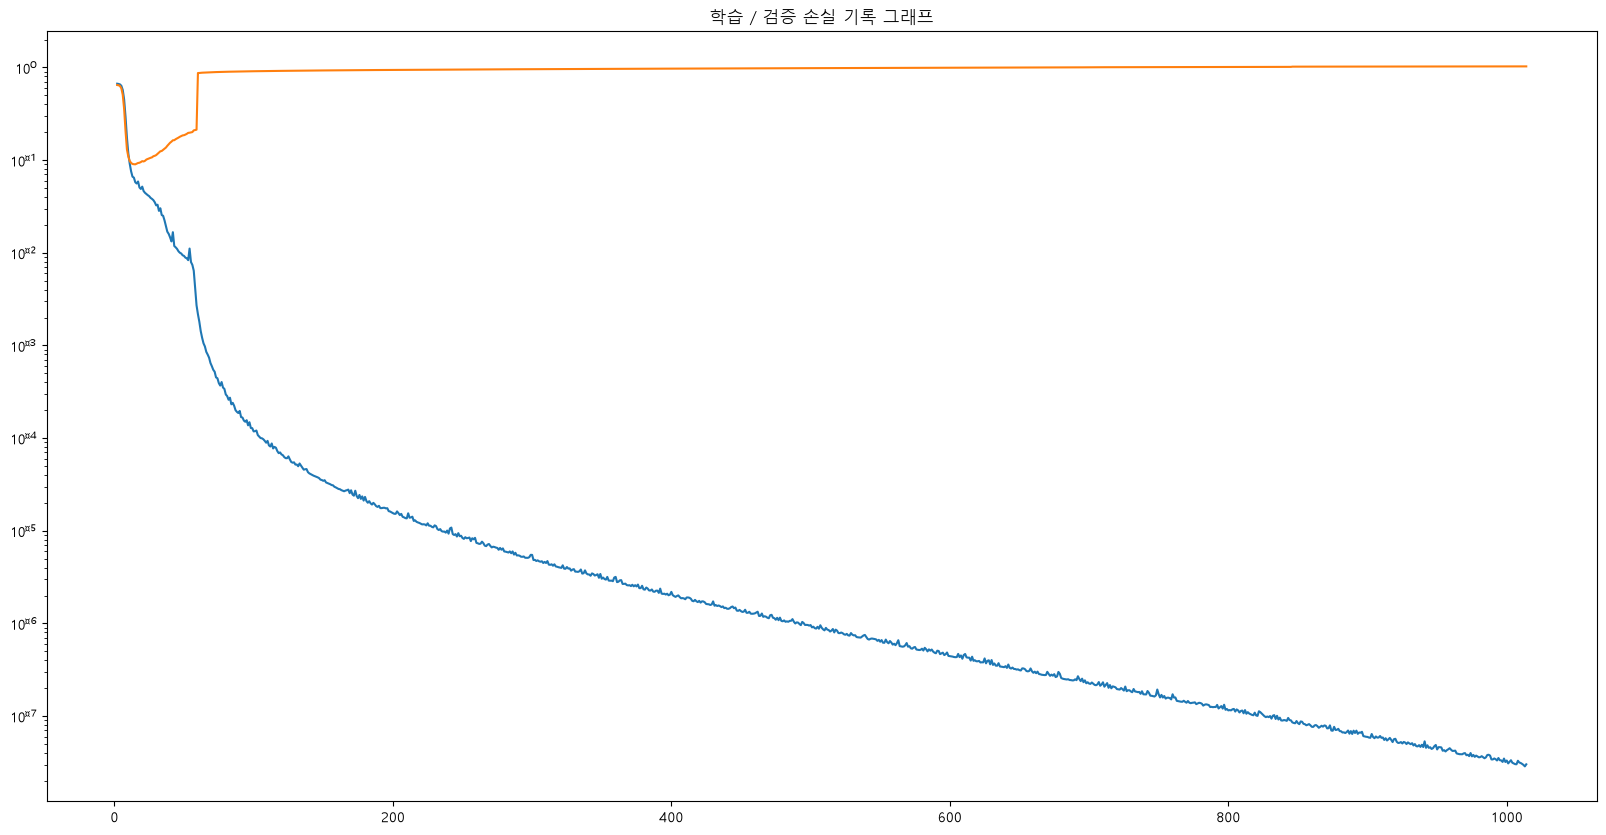

In [75]:
#한글 폰트 설정 (Mac은 AppleGothic)
plt.rcParams["font.family"] = "Malgun Gothic"

#마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

plot_from = 2 # 0번, 1번 초반 에폭은 불안정하므로 3번째부터 에폭부터 사용하기 위한 설정

plt.figure(figsize = (20,10))
plt.grid = True
plt.title("학습 / 검증 손실 기록 그래프")

# 학습 / 검증 손실 곡선
plt.plot(
    range(plot_from, len(train_history)), train_history[plot_from:],
    range(plot_from, len(valid_history)), valid_history[plot_from:],
)
plt.yscale('log')
plt.show()

7. 테스트 데이터로 결과확인

In [80]:
test_loss = 0
y_hat = []

with torch.no_grad():
    x_ = x[2].split(batch_size, dim = 0)   # 테스트 데이터 배치 분할
    y_ = y[2].split(batch_size, dim = 0)   # 테스트 데이터 배치 분할

    valid_loss = 0

    # 배치단위로 검증 데이터 순회
    for x_i, y_i in zip(x_, y_):
        y_hat_i = model(x_i)   # 순전파 (예측)
        loss = F.binary_cross_entropy(y_hat_i, y_i)  # 검증 손실 계산

        test_loss += float(loss)   # epochs별 test_loss 총합

        y_hat += [y_hat_i]          # 예측값 저장

test_loss = test_loss / len(x_)   # 평균 검증 손실
y_hat = torch.cat(y_hat, dim = 0) # 배치별 예측 결과를 하나의 Tensor로 결합

print(f"Test Loss : {test_loss}")

Test Loss : 0.09387615881860256


In [81]:
correct_cnt = (y[2] == (y_hat > .5)).sum()
total_cnt = float(y[2].size(0))

print(f"테스트 정확도는? {correct_cnt/total_cnt * 100:.2f}%")

테스트 정확도는? 97.39%


y_hat > .5 : 예측 확률이 0.5보다 크면 True, dkslaus False
y[2] == : True = 1, False = 0 각각 맞는지 True, False 반환

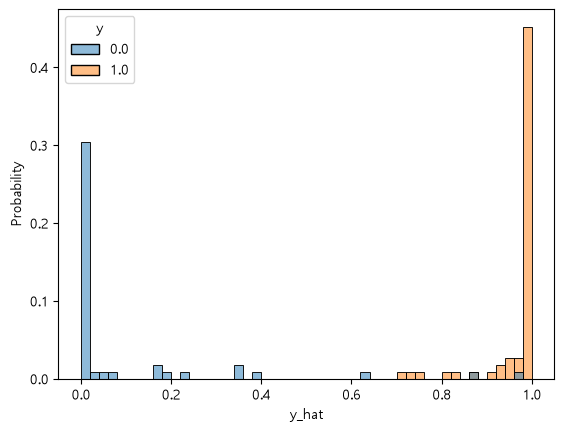

In [83]:
# 시각화
df = pd.DataFrame(
    torch.cat([y[2],y_hat], dim = 1) # 실제값과 예측값을 열 방향으로 합침
    .detach()                        # autograd 그래프에서 분리
    .numpy(),                        # numpy 배열 형태로 변환
    columns = ["y","y_hat"]          
)

sns.histplot(
    df, x = 'y_hat',        # x축: 모델 예측값
    hue = 'y',              # 색상 구분: 실제 데이터
    bins = 50, 
    stat ='probability')    # 빈도를 확률(비율)로 정규화

plt.show()

확신을 가지고 선택한 결과가 많아 모델 학습이 잘 된것으로 보임

In [84]:
from sklearn.metrics import roc_auc_score

roc_auc_score(
    df.values[:, 0],  # 실제값 (0 또는 1)
    df.values[:, 1],  # 예측 확률값 (0~1)
)

0.9944029850746269

roc기준 1.0 -> 완벽한 분류
0.5 -> 랜덤 추측 수준